# **MODELLO DEFINITIVO: `VotingClassifier`**

### Preparazione dati

Leggo il nostro dict in `.pkl`

In [3]:
import pickle as pkl

with open('../data/ottani_NIR.pkl', 'rb') as f:
    dizionario = pkl.load(f)
    
# dati train
train_ones = dizionario['train']['NIR']['ones']
train_zeros = dizionario['train']['NIR']['zeros']
train_labels = dizionario['train']['labels']

# dati test
test_ones = dizionario['test']['NIR']['ones']
test_zeros = dizionario['test']['NIR']['zeros']
test_labels = dizionario['test']['labels']


In [4]:
import numpy as np

train_x = np.concatenate((train_zeros, train_ones))
test_x = np.concatenate((test_zeros,test_ones))


importo neural network

In [5]:
from ML_app.single_neuron import single_neuron as neural_network

---

### SMOOTHING 

In [6]:
from scipy.signal import savgol_filter

window_size = 11
poly_order = 3

for i in range(train_x.shape[0]):
    train_x[i] = savgol_filter(train_x[i], window_size, poly_order)

for j in range(test_x.shape[0]):
    test_x[j] = savgol_filter(test_x[j], window_size, poly_order)

---

In [7]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier as RFC

In [8]:
random_state=None

### Migliori modelli trovati

In [9]:
nn_best = neural_network(epoche=1_000_000, nn_learning_rate=0.1, convergence_tol=0.005, activation_function='tanh', random_state=random_state)
#nn_best = neural_network(epoche=20_000, nn_learning_rate=0.5, activation_function='sigmoide', random_state=random_state)
#nn_best = neural_network(epoche=100_000, nn_learning_rate=0.9, activation_function='sigmoide', random_state=random_state)

svm_best = SVC(C=5, kernel='linear', random_state=random_state, probability=True)

#rf_best = RFC(criterion='entropy', max_depth=5, max_features='log2', min_samples_leaf=1, n_estimators=100, random_state=random_state)
#rf_best = RFC(criterion='entropy', max_depth=3, max_features='log2', min_samples_leaf=1, n_estimators=250, random_state=random_state)
rf_best = RFC(criterion='gini', max_depth=3, max_features='sqrt', min_samples_leaf=1, n_estimators=50, random_state=random_state)

nn_pipe = Pipeline([
    # Step 1: Scaling
    ("scaling", MinMaxScaler()),       
    
    # Step 2: Riduzione dimensionalità (PCA)
    ("reduce_dim", PCA(n_components=5)),
    
    # Step 3: Classificatore
    ("classify", nn_best) 
])

svm_pipe = Pipeline([
    # Step 1: Scaling
    ("scaling", MinMaxScaler()),       
    
    # Step 2: Riduzione dimensionalità (PCA)
    ("reduce_dim", PCA(n_components=5)),
    
    # Step 3: Classificatore
    ("classify", svm_best) 
])

rf_pipe = Pipeline([
    # Step 1: Scaling
    ("scaling", MinMaxScaler()),       
    
    # Step 2: Riduzione dimensionalità (PCA)
    ("reduce_dim", PCA(n_components=19)),
    
    # Step 3: Classificatore
    ("classify", rf_best) 
])

## **SU QUALI SPETTRI SBAGLIANO I MODELLI?**

Facciamo un istogramma che mostra, durante cross-validation, quali sono gli spettri (tra i 48) su cui sbagliano di più i modelli. Vogliamo vedere se sbagliano tutti e tre nello stesso posto, oppure no. Perché se sbagliano tutti gli stessi spettri, non ha senso usare il majority rule!

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.base import clone

# possiamo anche farlo su più di 10 ripetizioni
n_repeats = 50

# Prepariamo gli array lunghi 48 riempiti di zeri
N_campioni = len(train_x)
errori_svm = np.zeros(N_campioni)
errori_rf = np.zeros(N_campioni)
errori_nn = np.zeros(N_campioni)

# Prepariamo le liste per raccogliere l'accuracy di ogni fold
scores_svm = []
scores_rf = []
scores_nn = []

rkf = RepeatedStratifiedKFold(n_splits=6, n_repeats=n_repeats, random_state=random_state)

# iteriamo sui fold
for train_index, test_index in rkf.split(train_x, train_labels):
    
    # Creiamo i set per questo specifico split
    X_train_fold, X_test_fold = train_x[train_index], train_x[test_index]
    y_train_fold, y_test_fold = train_labels[train_index], train_labels[test_index]
    
    # --- Modello SVM ---
    clone_svm = clone(svm_pipe).fit(X_train_fold, y_train_fold)
    pred_svm = clone_svm.predict(X_test_fold)
    
    errori_svm[test_index] += (pred_svm != y_test_fold)
    scores_svm.append(np.mean(pred_svm == y_test_fold)) # Calcolo accuracy del fold
    
    # --- Modello Random Forest ---
    clone_rf = clone(rf_pipe).fit(X_train_fold, y_train_fold)
    pred_rf = clone_rf.predict(X_test_fold)
    
    errori_rf[test_index] += (pred_rf != y_test_fold)
    scores_rf.append(np.mean(pred_rf == y_test_fold)) # Calcolo accuracy del fold
    
    # --- Modello Neurone ---
    clone_nn = clone(nn_pipe).fit(X_train_fold, y_train_fold)
    pred_nn = clone_nn.predict(X_test_fold)
    
    errori_nn[test_index] += (pred_nn != y_test_fold)
    scores_nn.append(np.mean(pred_nn == y_test_fold)) # Calcolo accuracy del fold
    
svm_mean_acc = np.mean(scores_svm)
svm_std_acc = np.std(scores_svm)

rf_mean_acc = np.mean(scores_rf)
rf_std_acc = np.std(scores_rf)

nn_mean_acc = np.mean(scores_nn)
nn_std_acc = np.std(scores_nn)

# --- STAMPA DEI RISULTATI ---
print("--- RISULTATI ACCURACY (Cross-Validation) ---")
print(f"SVM          : {svm_mean_acc:.4f} ± {svm_std_acc:.4f}")
print(f"Random Forest: {rf_mean_acc:.4f} ± {rf_std_acc:.4f}")
print(f"Neurone      : {nn_mean_acc:.4f} ± {nn_std_acc:.4f}")


--- RISULTATI ACCURACY (Cross-Validation) ---
SVM          : 0.9725 ± 0.0593
Random Forest: 0.8912 ± 0.1041
Neurone      : 0.9496 ± 0.0979


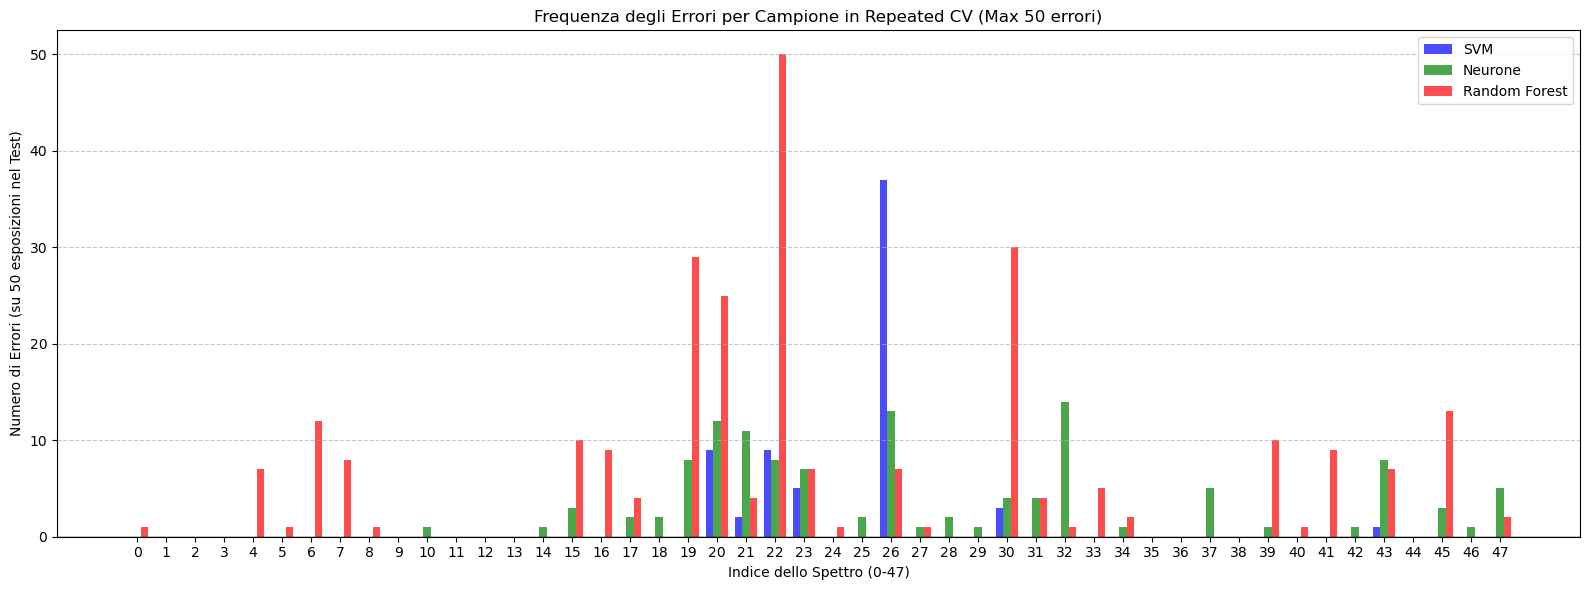

In [11]:
# Grafico
indici = np.arange(N_campioni)
larghezza_barra = 0.25

plt.figure(figsize=(16, 6))

# Creiamo tre barre affiancate per ogni campione
plt.bar(indici - larghezza_barra, errori_svm, width=larghezza_barra, label='SVM', color='blue', alpha=0.7)
plt.bar(indici, errori_nn, width=larghezza_barra, label='Neurone', color='green', alpha=0.7)
plt.bar(indici + larghezza_barra, errori_rf, width=larghezza_barra, label='Random Forest', color='red', alpha=0.7)

plt.title(f'Frequenza degli Errori per Campione in Repeated CV (Max {n_repeats} errori)')
plt.xlabel('Indice dello Spettro (0-47)')
plt.ylabel(f'Numero di Errori (su {n_repeats} esposizioni nel Test)')
plt.xticks(indici) # Mostra tutti i numerini sull'asse X
plt.axhline(0, color='black', linewidth=1)
#plt.yticks(np.arange(n_repeats+1)) # Asse Y va da 0 a n_repeats+1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.show()

> ⚠️ **Tutti e tre sbagliano spessissimo sul 22!**

> ‼️ Neural network sbaglia con molta convinzione il 26, mentre gli altri due (almeno nell'ultima ripetizione) no

In [12]:
print('svm', clone_svm.predict_proba(train_x)[22])
print('nn', clone_nn.predict_proba(train_x)[22])
print('rf', clone_rf.predict_proba(train_x)[22])

svm [0.48946346 0.51053654]
nn [0.53550513 0.46449487]
rf [0.62390645 0.37609355]


In [13]:
# TODO: sistemare single_neuron.predict_proba() per attivazioni tanh e ReLU

---

## **MODELLO FINALE**

funzione per testare prediction con stratified k fold ripetuto

In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, accuracy_score

def benchmark_interno(
    estimator,
    train_data,
    train_labels,
    n_repeats
):
    score_interno = np.zeros(n_repeats)
    sensitivity_interna = np.zeros(n_repeats)
    specificity_interna = np.zeros(n_repeats)
    
    for i in range(n_repeats):
        skf = StratifiedKFold(n_splits=6, shuffle=True)
        
        # predictions
        predictions_interne = cross_val_predict(estimator, train_data, train_labels, cv=skf, n_jobs=-1)
        # punteggi
        score_interno[i] = (accuracy_score(y_true=train_labels, y_pred=predictions_interne))
        sensitivity_interna[i] = (recall_score(y_true=train_labels, y_pred=predictions_interne))
        specificity_interna[i] = (recall_score(y_true=train_labels, y_pred=predictions_interne, pos_label=0))
        
    return score_interno, sensitivity_interna, specificity_interna

In [15]:
from sklearn.ensemble import VotingClassifier

# Supponiamo tu abbia i tuoi 3 modelli già configurati con i best_params
clf_svm = clone(svm_pipe)
clf_nn = clone(nn_pipe)
clf_rf = clone(rf_pipe)

# Pesi basati sull'accuracy della CV divisi per la std!
pesi = [svm_mean_acc/svm_std_acc, nn_mean_acc/nn_std_acc, rf_mean_acc/rf_std_acc]

ensemble = VotingClassifier(
    estimators=[
        ('svm', clf_svm), 
        ('neurone', clf_nn), 
        ('random_forest', clf_rf)
    ],
    voting='hard', # 'hard': regola della maggioranza
    weights=pesi
)

# Valutiamo accuracy su dataset di addestramento
score_interno, sensitivity_interna, specificity_interna = benchmark_interno(
    estimator=ensemble,
    train_data=train_x,
    train_labels=train_labels,
    n_repeats=n_repeats
)

print('test interno:')
print(f'- accuracy {np.mean(score_interno):.2f}±{np.std(score_interno):.2f}\
        \n- sensitivity {np.mean(sensitivity_interna):.2f}±{np.std(sensitivity_interna):.2f}\
        \n- specificity {np.mean(specificity_interna):.2f}±{np.std(specificity_interna):.2f}')
          
          
# poi per fare test esterno lo addestro su tutto il train set
ensemble.fit(train_x, train_labels)


predizioni_test_esterno = ensemble.predict(test_x)

score_esterno = accuracy_score(test_labels, predizioni_test_esterno)
sensitivity_esterna = recall_score(test_labels, predizioni_test_esterno)
specificity_esterna = recall_score(test_labels, predizioni_test_esterno, pos_label=0)

print('test esterno:')
print(f'- accuracy {score_esterno:.2f}\
        \n- sensitivity {sensitivity_esterna:.2f}\
        \n- specificity {specificity_esterna:.2f}')


test interno:
- accuracy 0.98±0.02        
- sensitivity 0.98±0.02        
- specificity 0.97±0.04
test esterno:
- accuracy 1.00        
- sensitivity 1.00        
- specificity 1.00


Prima era il 22 che dava noia, ora sembrano prenderle tutte.

In [16]:
predizioni_test_interno = ensemble.predict(train_x)
predizioni_test_interno

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [17]:
ensemble.score(train_x, train_labels)

1.0

Ma, per qualche oscuro motivo, ora sul test set sbagliano quello con ottani più alti, che dovrebbe essere il più facile.

In [18]:
predizioni_test_esterno = ensemble.predict(test_x)
predizioni_test_esterno

array([0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.])